# 📊 SignAlign - Análise de Experimentos

Este notebook carrega automaticamente todos os experimentos da pasta `experiments/` e permite:

1. **Comparação de métricas** entre diferentes configurações
2. **Visualização de curvas** de treinamento
3. **Análise qualitativa** com attention maps
4. **Matriz de similaridade** para pares específicos


In [1]:
# Imports
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Adicionar path do projeto
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from signalign.inference import SignaturePredictor, SimilarityMatrixVisualizer, plot_retrieval_results
from signalign.explainability import visualize_attention
from signalign.utils.seed import get_device

# Configurações de plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print(f"📁 Diretório do projeto: {project_root}")


ModuleNotFoundError: No module named 'pandas'

## 1. 📂 Carregar Experimentos


In [ ]:
def load_all_experiments(experiments_dir: str = "experiments"):
    """Carrega todos os experimentos de um diretório."""
    exp_path = project_root / experiments_dir
    experiments = []
    
    if not exp_path.exists():
        print(f"⚠️ Diretório {exp_path} não encontrado.")
        return pd.DataFrame()
    
    for exp_dir in exp_path.iterdir():
        if not exp_dir.is_dir():
            continue
        
        metadata_path = exp_dir / "metadata.json"
        config_path = exp_dir / "config.json"
        val_history_path = exp_dir / "metrics" / "val_history.json"
        
        exp_data = {"name": exp_dir.name, "path": str(exp_dir)}
        
        if metadata_path.exists():
            with open(metadata_path) as f:
                metadata = json.load(f)
                exp_data["best_epoch"] = metadata.get("best_epoch")
                exp_data["best_metric"] = metadata.get("best_metric", {})
        
        if config_path.exists():
            with open(config_path) as f:
                config = json.load(f)
                exp_data["model_type"] = config.get("model", {}).get("type")
                exp_data["loss_type"] = config.get("loss", {}).get("primary_loss")
                exp_data["use_triplet"] = config.get("loss", {}).get("use_triplet_loss")
                exp_data["freeze_vision"] = config.get("model", {}).get("freeze_vision_encoder")
        
        if val_history_path.exists():
            with open(val_history_path) as f:
                val_history = json.load(f)
                if val_history:
                    for key, value in val_history[-1].items():
                        if key.startswith("val_"):
                            exp_data[key] = value
        
        experiments.append(exp_data)
    
    df = pd.DataFrame(experiments)
    print(f"✅ {len(df)} experimentos carregados.")
    return df

# Carregar experimentos
df_experiments = load_all_experiments()
display(df_experiments)


✅ 3 experimentos carregados.


,name,path,best_epoch,best_metric,model_type,loss_type,use_triplet,freeze_vision,val_accuracy_1_neg,val_eer_1_neg,...,val_recall@10_2_neg,val_accuracy_3_neg,val_eer_3_neg,val_eer_threshold_3_neg,val_auc_3_neg,val_mrr_3_neg,val_ndcg_3_neg,val_recall@1_3_neg,val_recall@5_3_neg,val_recall@10_3_neg
0,clip_base_vit_b32,/home/lucas/Documentos/PósGaduação/UFPR/Mestra...,1,{'accuracy_3_neg': 0.4},clip,cross_entropy,True,False,0.8,0.400000,...,1.0,0.4,0.400000,0.214223,0.76,0.700000,0.778558,0.4,1.0,1.0
1,baseline_tinyclip,/home/lucas/Documentos/PósGaduação/UFPR/Mestra...,1,{'accuracy_3_neg': 0.3333333333333333},tinyclip,cross_entropy,True,False,1.0,0.333333,...,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,siglip_sigmoid_loss,/home/lucas/Documentos/PósGaduação/UFPR/Mestra...,1,{'accuracy_3_neg': 0.2},siglip,sigmoid,False,False,0.2,0.800000,...,1.0,0.0,0.666667,0.018850,0.32,0.333333,0.498457,0.0,1.0,1.0


## 2. 📈 Comparação de Métricas


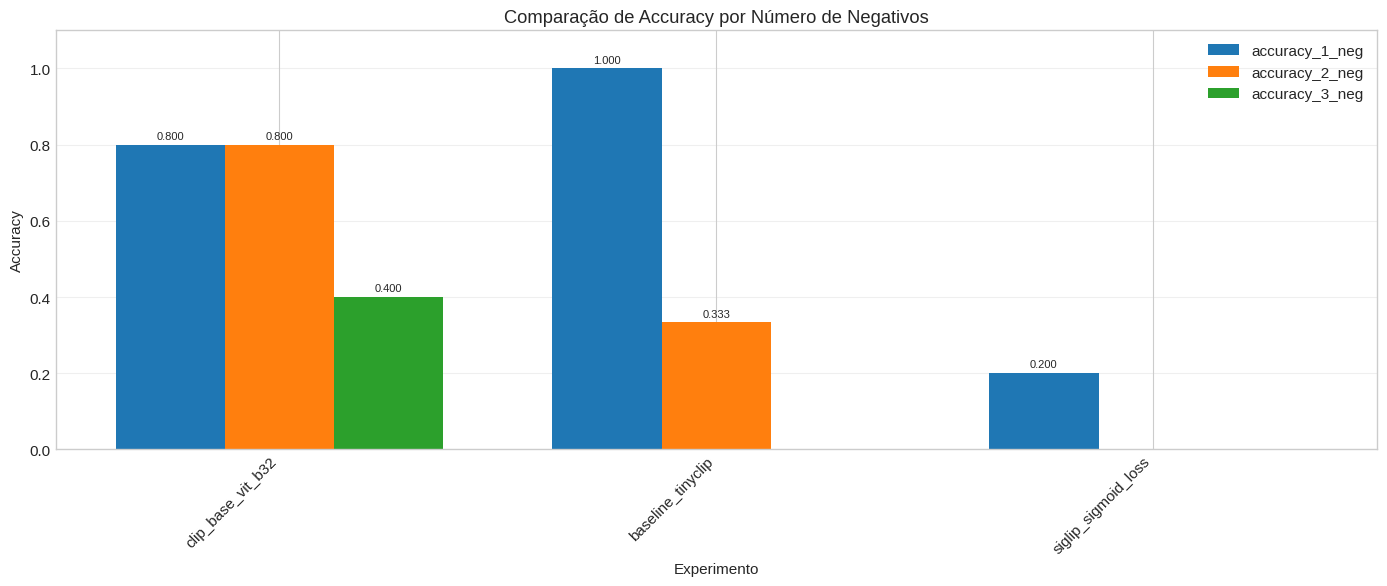

In [3]:
def plot_metrics_comparison(df, metrics=["val_accuracy_1_neg", "val_accuracy_2_neg", "val_accuracy_3_neg"]):
    """Plota comparação de métricas entre experimentos."""
    if df.empty:
        print("⚠️ Nenhum experimento para comparar.")
        return
    
    available_metrics = [m for m in metrics if m in df.columns]
    if not available_metrics:
        print(f"⚠️ Métricas não encontradas.")
        return
    
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(df))
    width = 0.25
    
    for i, metric in enumerate(available_metrics):
        values = df[metric].fillna(0)
        bars = ax.bar(x + i * width, values, width, label=metric.replace("val_", ""))
        for bar, val in zip(bars, values):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    
    ax.set_xlabel('Experimento')
    ax.set_ylabel('Accuracy')
    ax.set_title('Comparação de Accuracy por Número de Negativos')
    ax.set_xticks(x + width)
    ax.set_xticklabels(df['name'], rotation=45, ha='right')
    ax.legend()
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

if not df_experiments.empty:
    plot_metrics_comparison(df_experiments)


## 3. 🔍 Carregar Modelo para Inferência


In [4]:
# Selecionar experimento para análise (modifique conforme necessário)
# Opções: "baseline_tinyclip", "clip_base_vit_b32", "siglip_sigmoid_loss", ou None para auto-selecionar
SELECTED_EXPERIMENT = "baseline_tinyclip"

predictor = None
if not df_experiments.empty:
    if SELECTED_EXPERIMENT:
        exp_row = df_experiments[df_experiments['name'] == SELECTED_EXPERIMENT].iloc[0]
    else:
        # Usar o melhor experimento
        best_col = [c for c in df_experiments.columns if 'accuracy_3' in str(c)]
        if best_col:
            exp_row = df_experiments.loc[df_experiments[best_col[0]].idxmax()]
        else:
            exp_row = df_experiments.iloc[0]
    
    print(f"📌 Experimento selecionado: {exp_row['name']}")
    print(f"   Tipo: {exp_row.get('model_type', 'unknown')}")
    print(f"   Path: {exp_row['path']}")
    
    try:
        predictor = SignaturePredictor.from_experiment(
            exp_row['path'],
            checkpoint="best",
            model_type=exp_row.get('model_type', 'tinyclip')
        )
        print("✅ Modelo carregado com sucesso!")
    except Exception as e:
        print(f"⚠️ Erro ao carregar modelo: {e}")
        import traceback
        traceback.print_exc()
else:
    print("⚠️ Nenhum experimento encontrado.")


📌 Experimento selecionado: baseline_tinyclip
   Tipo: tinyclip
   Path: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlign/experiments/baseline_tinyclip
📦 Carregando modelo de: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlign/experiments/baseline_tinyclip/checkpoints/best


Loading weights:   0%|          | 0/302 [00:00<?, ?it/s]

📂 Modelo carregado de: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlign/experiments/baseline_tinyclip/checkpoints/best
✅ Modelo carregado em cpu
✅ Modelo carregado com sucesso!


## 4. 📊 Matriz de Similaridade


In [5]:
# Carregar dataset
dataset_path = project_root / "datasets" / "dataset-sign-align" / "dataset.csv"
df_dataset = None

if dataset_path.exists():
    df_dataset = pd.read_csv(dataset_path)
    df_dataset = df_dataset[df_dataset['human_name'] != 'UNKNOWN'].reset_index(drop=True)
    print(f"📊 Dataset carregado: {len(df_dataset)} amostras")
    display(df_dataset.head())
else:
    print(f"⚠️ Dataset não encontrado em: {dataset_path}")


📊 Dataset carregado: 3647 amostras


,document,human_name,llm_name,image_path,source
0,efm53d00,A A MACKINNON,A MACKINNON,signatures/efm53d00_sign3.png,outros
1,cxk72e00-page03_3,ADOLFO KUENNEN,ADOLFO KUENNEN,signatures/cxk72e00-page03_3_sign1.png,outros
2,gsa_LAL50124-SLA-1-_Z-01,ADRIANA SANCHEZ,CHAD SANDS,signatures/gsa_LAL50124-SLA-1-_Z-01_sign3.png,gsa
3,X_031,ALAN X HUM,ALAN L HUM,signatures/X_031_sign1.png,x_dataset
4,nist_r0025_01,ALBUR R BELL,ARTHUR T BELL,signatures/nist_r0025_01_sign2.png,nist



📊 Matriz de Similaridade (5x5)


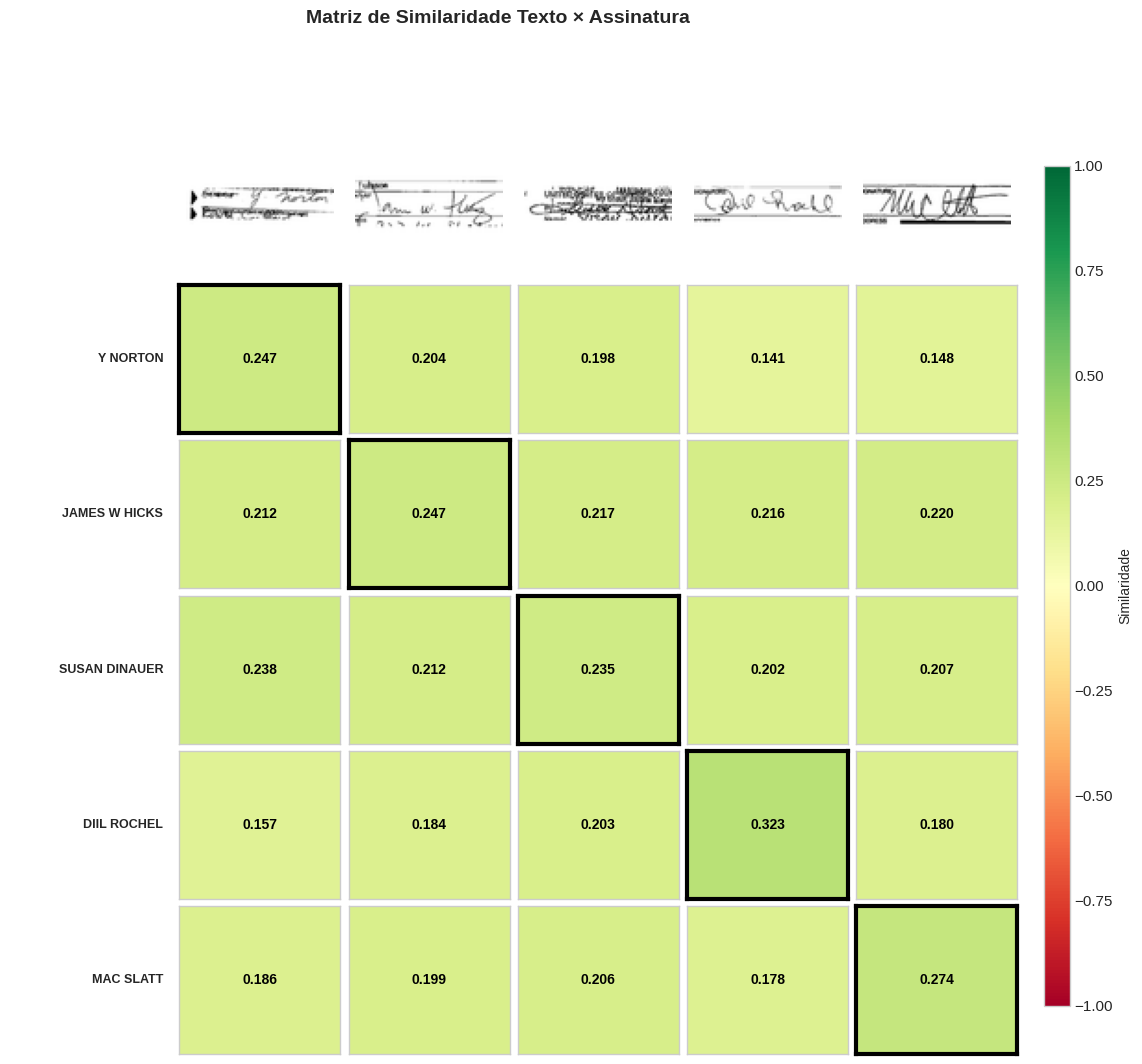

In [6]:
# Criar matriz de similaridade para N textos e N imagens
if predictor is not None and df_dataset is not None:
    N = 5  # Número de amostras
    unique_names = df_dataset['human_name'].unique()
    selected_names = np.random.choice(unique_names, min(N, len(unique_names)), replace=False)
    
    # Base path para imagens
    images_base_path = project_root / "datasets" / "dataset-sign-align"
    
    texts = []
    images = []
    for name in selected_names:
        sample = df_dataset[df_dataset['human_name'] == name].iloc[0]
        texts.append(name)
        # Construir caminho completo da imagem
        img_path = images_base_path / sample['image_path']
        images.append(str(img_path))
    
    print(f"\n📊 Matriz de Similaridade ({N}x{N})")
    
    visualizer = SimilarityMatrixVisualizer(predictor)
    sim_matrix = visualizer.plot_similarity_matrix(
        texts=texts,
        images=images,
        title="Matriz de Similaridade Texto × Assinatura",
        highlight_diagonal=True
    )
else:
    print("⚠️ Predictor ou dataset não disponível.")


## 5. 🎯 Predição com Attention Map


In [7]:
# Fazer predição com visualização de atenção
if predictor is not None and df_dataset is not None:
    sample = df_dataset.sample(1).iloc[0]
    
    # Base path para imagens
    images_base_path = project_root / "datasets" / "dataset-sign-align"
    image_path = str(images_base_path / sample['image_path'])
    
    print(f"🔍 Teste com:")
    print(f"   Nome: {sample['human_name']}")
    print(f"   Imagem: {image_path}")
    
    result = predictor.predict_with_visualization(
        text=sample['human_name'],
        image_path=image_path,
        show=True
    )
    print(f"\n📊 Similaridade: {result['similarity']:.4f}")


🔍 Teste com:
   Nome: HEMER S LIM
   Imagem: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlign/datasets/dataset-sign-align/signatures/nist_r0263_01_sign2.png


ValueError: Modelo não retornou attention maps. Este modelo pode não suportar visualização de atenção.

In [ ]:
predictor.model.eval()

TinyCLIPWrapper(
  (model): CLIPModel(
    (text_model): CLIPTextTransformer(
      (embeddings): CLIPTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-5): 6 x CLIPEncoderLayer(
            (self_attn): CLIPAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (activation_fn): GELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=2048, out_features=512, bias=True)
      